In [8]:
# from unconditional_model import Unet256
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.io import read_image
from torch.nn import functional as F

In [9]:
class AttentionBlock(nn.Module):
    def __init__(self, channels, n_heads=1):
        super().__init__()
        self.channels = channels
        self.norm = nn.GroupNorm(32, channels)
        self.inner_dim = channels // 4

        self.q = nn.Conv2d(channels, self.inner_dim, kernel_size=1, bias=False)
        self.k = nn.Conv2d(channels, self.inner_dim, kernel_size=1, bias=False)
        self.v = nn.Conv2d(channels, channels, kernel_size=1, bias=False)

        self.proj_out = nn.Conv2d(channels, channels, kernel_size=1, bias=False)
        self.scale = self.inner_dim ** (-0.5)

    def forward(self, x):
        b, c, h, w = x.shape
        n = h * w
        h_ = self.norm(x)
        
        q = self.q(h_).view(b, self.inner_dim, n)
        k = self.k(h_).view(b, self.inner_dim, n)
        v = self.v(h_).view(b, c, n)

        attn = torch.einsum('b d i, b d j -> b i j', q, k)
        attn = torch.softmax(self.scale * attn, dim=-1)

        out = torch.einsum('b i j, b c j -> b c i', attn, v)

        out = out.view(b, c, h, w)
        return x + self.proj_out(out)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim, groups=32):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.norm2 = nn.GroupNorm(groups, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        self.time_mlp = nn.Linear(time_dim, out_channels)

        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
        self.activation = F.silu

    def forward(self, x, time_embedding):
        h = self.norm1(x)
        h = self.activation(h)
        h = self.conv1(h)
                                  
        bias = self.time_mlp(self.activation(time_embedding))
        h = h + bias[:, :, None, None]

        h = self.norm2(h)
        h = self.activation(h)
        h = self.conv2(h)

        return h + self.shortcut(x)

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_dim)
        self.down = nn.Conv2d(out_channels, out_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x, time_embedding):
        x = self.res(x, time_embedding)
        return x, self.down(x)

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_dim)
        self.conv = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x, skip, time_embedding):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = torch.cat([x, skip], dim=1)
        x = self.res(x, time_embedding)
        return self.conv(x)

class Unet256(nn.Module):
    def __init__(self, in_channels=1, time_dim=256):
        super().__init__()
        self.time_dim = time_dim
        
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.init_conv = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)

        self.downs = nn.ModuleList([
            DownBlock(64, 128, time_dim),
            DownBlock(128, 256, time_dim),
            DownBlock(256, 512, time_dim),
            DownBlock(512, 512, time_dim),
            DownBlock(512, 512, time_dim)
        ])

        self.bottleneck = nn.ModuleList([
            ResidualBlock(512, 512, time_dim),
            AttentionBlock(512),
            ResidualBlock(512, 512, time_dim)
        ])

        self.ups = nn.ModuleList([
            UpBlock(1024, 512, time_dim),
            UpBlock(1024, 512, time_dim),
            UpBlock(1024, 256, time_dim),
            UpBlock(512, 128, time_dim),
            UpBlock(256, 64, time_dim)
        ])

        self.final_conv = nn.Conv2d(64, in_channels, kernel_size=1)

    def forward(self, x, time):
        time = self.time_embedding(time, self.time_dim)
        time = self.time_mlp(time)

        x = self.init_conv(x)

        skips = []
        for down in self.downs:
            skip, x = down(x, time)
            skips.append(skip)

        for block in self.bottleneck:
            if isinstance(block, ResidualBlock):
                x = block(x, time)
            else:
                x = block(x) 

        for up in self.ups:
            skip = skips.pop()
            x = up(x, skip, time)
            
        return self.final_conv(x)

    def time_embedding(self, t, dim):
        """
        n = dim
        t -> {sin(w1*t), cos(w1*t), ... sin(wn*t), cos(wn*t)}
        Args:
            t: [B, ]
            dim: scalar
        """
        idx = torch.arange(0, dim // 2, device=t.device)
        w = 1 / (10000 ** ((2 * idx) / dim))
        angles = t[:, None] * w[None, :]
        sin = torch.sin(angles)
        cos = torch.cos(angles)
        return torch.cat([sin, cos], dim=-1)

In [10]:
model = Unet256()
optimizer = optim.Adam(model.parameters())

checkpoint = torch.load('../models/v1/checkpoint_epoch_40.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
avg_loss = checkpoint['loss']

print(f"Resumed from epoch {epoch} with loss {avg_loss}")

Resumed from epoch 40 with loss 0.07249105064376211


In [11]:
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((t / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clamp(betas, 0.0001, 0.9999)

def time_embedding(t, dim):
    """
    n = dim
    t -> {sin(w1*t), cos(w1*t), ... sin(wn*t), cos(wn*t)}
    Args:
        t: [B, ]
        dim: scalar
    """
    idx = torch.arange(0, dim // 2, device=t.device)
    w = 1 / (10000 ** ((2 * idx) / dim))
    angles = t[:, None] * w[None, :]
    sin = torch.sin(angles)
    cos = torch.cos(angles)
    return torch.cat([sin, cos], dim=-1)

In [12]:
@torch.no_grad()
def sample(model, scheduler_params, shape, device):
    """
    Алгоритм итеративного денойзинга.
    shape: (Batch_size, Channels, H, W) -> (4, 1, 256, 256)
    """
    model.eval()
    
    betas = scheduler_params['betas'].to(device)
    alphas = scheduler_params['alphas'].to(device)
    alphas_cumprod = scheduler_params['alphas_cumprod'].to(device)
    T = len(betas)

    img = torch.randn(shape, device=device)

    for t in reversed(range(T)):
        t_batch = torch.full((shape[0],), t, device=device, dtype=torch.long)
        predicted_noise = model(img, t_batch)
        
        alpha_t = alphas[t]
        alpha_cumprod_t = alphas_cumprod[t]
        beta_t = betas[t]

        coeff = beta_t / torch.sqrt(1 - alpha_cumprod_t)
        mean = (1 / torch.sqrt(alpha_t)) * (img - coeff * predicted_noise)
        
        if t > 0:
            noise = torch.randn_like(img)
            sigma_t = torch.sqrt(beta_t)
            img = mean + sigma_t * noise
        else:
            img = mean
            
        img = torch.clamp(img, -1, 1)

    img = (img + 1) / 2
    return img

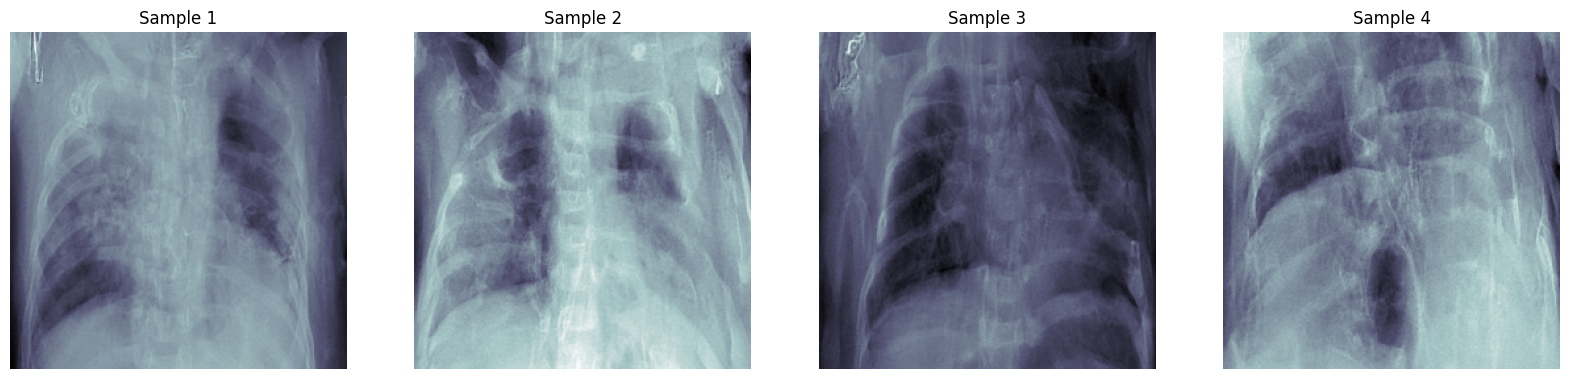

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

T = 1000
betas = cosine_beta_schedule(T)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

scheduler_params = {
    'alphas': alphas,
    'betas': betas,
    'alphas_cumprod': alphas_cumprod
}

with torch.no_grad():
    generated_images = sample(
        model=model,
        scheduler_params=scheduler_params,
        shape=(4, 1, 256, 256),
        device=device
    )

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(4):
    img = generated_images[i].cpu().squeeze().numpy()
    axes[i].imshow(img, cmap='bone')
    axes[i].axis('off')
    axes[i].set_title(f"Sample {i+1}")

plt.show()